# Desafio Pythonistico - Rossman Sales
## Análise Exploratória de Dados (EDA)
## Perguntas a serem respondidas
- O que impulsiona as vendas?
- Quais fatores são irrelevantes?
- Quais padrões vocês conseguem descobrir?
### Proibido uso de IA - Apenas para questionamentos e duvidas de codigo simples
### Ferramentas: 
- Linguagens de Programação: Python (com Pandas, Seaborn) ou R.
- Banco de Dados: SQL para fazer as consultas e agregações.
- Planilhas: O bom e velho Excel é super poderoso para análises e visualizações rápidas.
- pretty-jupyter: Relatorio final

# 0.0 Imports and VARIABLES

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0.1 Import assests CSV's

In [26]:
df_store = pd.read_csv('data/store.csv')
df_test = pd.read_csv('data/test.csv')
df_train = pd.read_csv('data/train.csv')
df_sample_submission = pd.read_csv('data/sample_submission.csv')

/tmp/ipykernel_24941/3525089753.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('data/train.csv')


# 0.2 Unique Sample

In [27]:
SAMPLES = 2
display("DF_store:", df_store.head(SAMPLES), "DF_test", df_test.head(SAMPLES), "DF_train", df_train.head(SAMPLES), "DF_sample_submission", df_sample_submission.head(SAMPLES))

'DF_store:'

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"


'DF_test'

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0


'DF_train'

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1


'DF_sample_submission'

,Id,Sales
0,1,0
1,2,0


# Explicação de cada planilha e colunas
Files
- train.csv - historical data including Sales
- test.csv - historical data excluding Sales
- sample_submission.csv - a sample submission file in the correct format
- store.csv - supplemental information about the stores
### Data fields

- Id - an Id that represents a (Store, Date) duple within the test set 
- Store - a unique Id for each store 
- Sales - the turnover for any given day (this is what you are predicting) 
- Customers - the number of customers on a given day
- Open - an indicator for whether the store was open: 0 = closed, 1 = open
- StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note       that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas,     0 = None
- SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools
- StoreType - differentiates between 4 different store models: a, b, c, d
- Assortment - describes an assortment level: a = basic, b = extra, c = extended // Q. Variedade de items na loja
- CompetitionDistance - distance in meters to the nearest competitor store
- CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
- Promo - indicates whether a store is running a promo on that day
- Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
- Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2
- PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

# Teoria pós sample:
Estamos tratando aparente de uma lista de arquivos usados para treinar uma inteligencia articial/ Analisar quantas vendas/clientes mediante Data, Dia da semana, promoção, Feriado e Feriado escolar

## suposições inicias para investigar
- Em dia de feriados, as vendas são maiores
- Feriado X Feriado Escolar
- Descobrir dia da semana que mais temos vendas
- Pegar grafico completo da historia de todas as lojas

# 1.0 Analise Exploratoria
## Detalhes das lojas

In [28]:
#extrair detalhes das lojas
print("Detalhes das lojas:")
print("[df_store] Tipos de lojas: \r\n {}".format(df_store['StoreType'].unique()))
display(df_store[df_store['StoreType'] == 'a'].describe())
display(df_store[df_store['StoreType'] == 'b'].describe())
display(df_store[df_store['StoreType'] == 'c'].describe())
display(df_store[df_store['StoreType'] == 'd'].describe())

Detalhes das lojas:
[df_store] Tipos de lojas: 
 ['c' 'a' 'd' 'b']


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,602.000000,601.000000,426.000000,426.000000,602.000000,289.000000,289.000000
mean,559.531561,5123.061564,7.180751,2008.549296,0.480066,24.072664,2011.882353
std,326.521514,8420.917544,3.243485,6.976509,0.500018,13.784486,1.732051
min,2.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,273.750000,460.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,557.500000,1790.000000,7.500000,2010.000000,0.000000,22.000000,2012.000000
75%,847.500000,5020.000000,10.000000,2012.000000,1.000000,37.000000,2013.000000
max,1114.000000,75860.000000,12.000000,2015.000000,1.000000,48.000000,2015.000000


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,17.000000,17.000000,9.000000,9.000000,17.000000,5.000000,5.000000
mean,561.470588,1060.588235,6.666667,2007.777778,0.294118,21.600000,2012.800000
std,297.699538,831.808802,2.872281,5.044249,0.469668,17.700282,0.447214
min,85.000000,90.000000,3.000000,1999.000000,0.000000,5.000000,2012.000000
25%,335.000000,590.000000,5.000000,2006.000000,0.000000,10.000000,2013.000000
50%,512.000000,900.000000,6.000000,2008.000000,0.000000,14.000000,2013.000000
75%,733.000000,1270.000000,9.000000,2011.000000,1.000000,31.000000,2013.000000
max,1097.000000,3640.000000,10.000000,2014.000000,1.000000,48.000000,2013.000000


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,148.000000,148.000000,107.000000,107.000000,148.000000,75.000000,75.000000
mean,608.148649,3522.567568,7.074766,2008.514019,0.506757,21.573333,2011.546667
std,326.218206,5944.811048,3.205835,4.272255,0.501652,14.859862,1.482268
min,1.000000,40.000000,1.000000,1994.000000,0.000000,1.000000,2009.000000
25%,364.250000,490.000000,4.000000,2006.000000,0.000000,13.000000,2010.500000
50%,619.500000,1660.000000,7.000000,2009.000000,1.000000,14.000000,2011.000000
75%,876.000000,3985.000000,10.000000,2012.000000,1.000000,35.000000,2013.000000
max,1112.000000,45740.000000,12.000000,2015.000000,1.000000,50.000000,2014.000000


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,348.000000,346.000000,219.000000,219.000000,348.000000,202.000000,202.000000
mean,533.853448,6913.063584,7.406393,2009.013699,0.580460,23.712871,2011.648515
std,312.107356,6769.367096,3.178794,5.380460,0.494194,14.331774,1.663247
min,13.000000,50.000000,1.000000,1961.000000,0.000000,1.000000,2009.000000
25%,251.500000,1880.000000,4.000000,2006.000000,0.000000,10.000000,2010.000000
50%,531.500000,5040.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,790.500000,9702.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.000000,48330.000000,12.000000,2015.000000,1.000000,49.000000,2015.000000


# Vamos lidar com o df_train e entender suas características

In [29]:
# Merge df_train com df_store para obter mais informações sobre as lojas
df_merged = pd.merge(df_train, df_store, on='Store', how='left')
df_merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [30]:
# Renomear as colunas para PT_BR para facilitar a vida
col_rename = {
    'Store': 'Loja',
    'DayOfWeek': 'DiaDaSemana',
    'Date': 'Data',
    'Sales': 'Vendas',
    'Customers': 'Clientes',
    'Open': 'Aberto',
    'Promo': 'Promocao',
    'StateHoliday': 'FeriadoEstadual',
    'SchoolHoliday': 'FeriadoEscolar',
    'StoreType': 'TipoLoja',
    'Assortment': 'TipoProduto',
    'CompetitionDistance': 'DistanciaCompeticao',
    'CompetitionOpenSinceMonth': 'MesAberturaCompeticao',
    'CompetitionOpenSinceYear': 'AnoAberturaCompeticao',
    'Promo2': 'Promocao2',
    'Promo2SinceWeek': 'SemanaInicioPromocao2',
    'Promo2SinceYear': 'AnoInicioPromocao2',
    'PromoInterval': 'IntervaloPromocao'
}

df_merged.rename(columns=col_rename, inplace=True)
df_merged.head(1)

,Loja,DiaDaSemana,Data,Vendas,Clientes,Aberto,Promocao,FeriadoEstadual,FeriadoEscolar,TipoLoja,TipoProduto,DistanciaCompeticao,MesAberturaCompeticao,AnoAberturaCompeticao,Promocao2,SemanaInicioPromocao2,AnoInicioPromocao2,IntervaloPromocao
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [ ]:
# Agrupamento por tipo de loja e cálculo da média de vendas
avg_sales_by_store_type = df_merged.groupby('TipoLoja')['Vendas'].mean().reset_index()
print("Média de vendas por tipo de loja:")
display(avg_sales_by_store_type)

# plotar gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_sales_by_store_type, x='TipoLoja', y='Vendas', palette='viridis', hue='TipoLoja')
plt.title('Média de Vendas por Tipo de Loja')
plt.xlabel('Tipo de Loja')
plt.ylabel('Média de Vendas')
plt.show()
print("Vemos que o tipo de loja 'b' tem a maior média de vendas.")

KeyError: 'StoreType'

In [ ]:
# Explorar quando começou e terminou a coleta de dados
df_train['Date'] = pd.to_datetime(df_train['Date'])
start_date = df_train['Date'].min()
end_date = df_train['Date'].max()
print(f"A coleta de dados começou em {start_date.date()} e terminou em {end_date.date()}.")

A coleta de dados começou em 2013-01-01 e terminou em 2015-07-31.


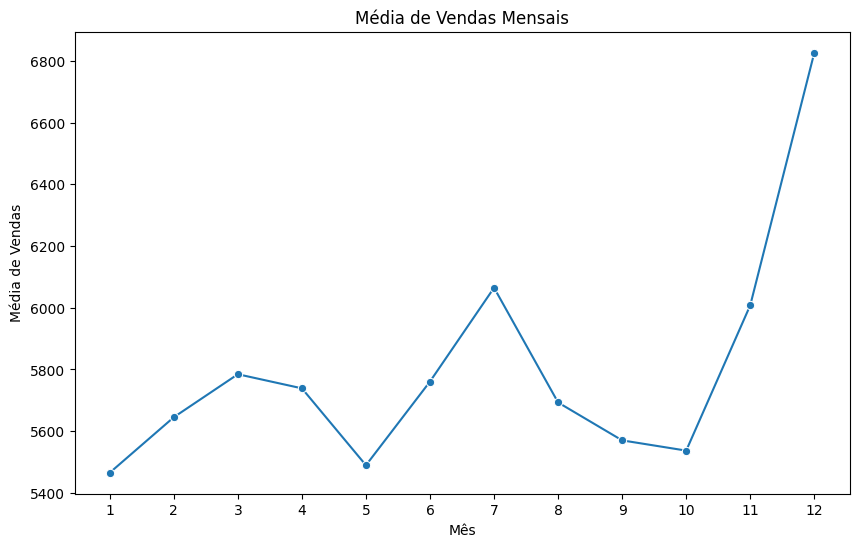

In [ ]:
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged['Month'] = df_merged['Date'].dt.month
monthly_sales = df_merged.groupby('Month')['Sales'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o')
plt.title('Média de Vendas Mensais Todas as lojas')
plt.xlabel('Mês')
plt.ylabel('Média de Vendas')
plt.xticks(range(1, 13))
plt.show()

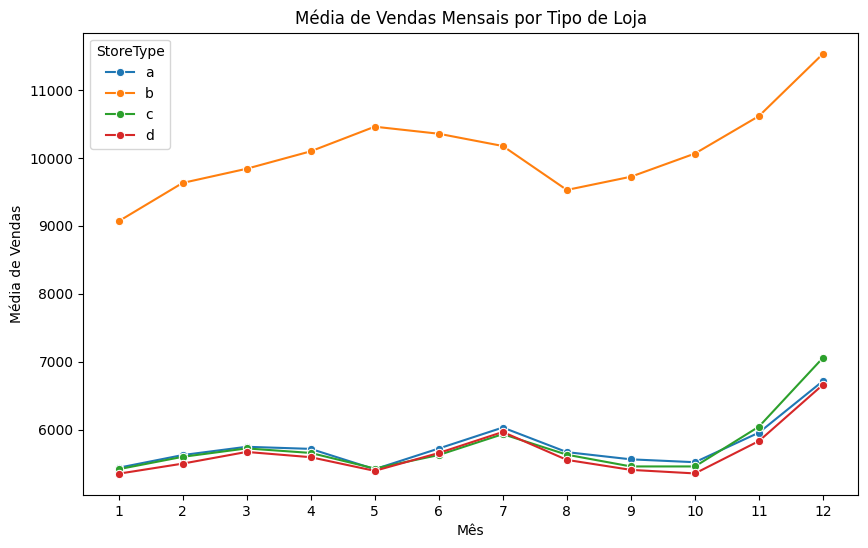

In [ ]:
# media de vendas mensais por tipo de loja
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged['Month'] = df_merged['Date'].dt.month
monthly_sales = df_merged.groupby(['Month', 'StoreType'])['Sales'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='StoreType', marker='o')
plt.title('Média de Vendas Mensais por Tipo de Loja')
plt.xlabel('Mês')
plt.ylabel('Média de Vendas')
plt.xticks(range(1, 13))
plt.show()

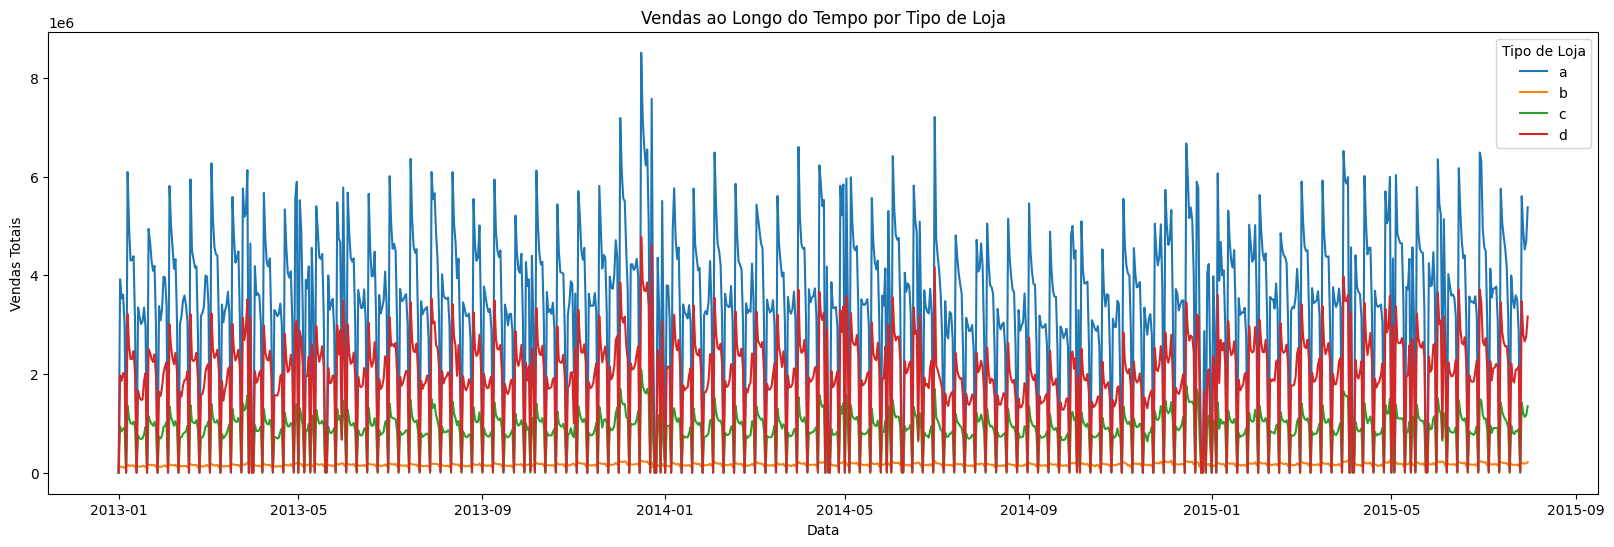

Observamos tendências sazonais nas vendas ao longo do tempo para diferentes tipos de lojas.


In [ ]:
## Grafico ta ferrado
# # grafico de linhas para vendas ao longo do tempo por tipo de loja
# df_merged['Data'] = pd.to_datetime(df_merged['Data']) # transformar a coluna Date em datetime
# sales_over_time = df_merged.groupby(['Data', 'TipoLoja'])['Vendas'].sum().reset_index()
# plt.figure(figsize=(20, 6))
# sns.lineplot(data=sales_over_time, x='Data', y='Vendas', hue='TipoLoja', palette='tab10')
# plt.title('Vendas ao Longo do Tempo por Tipo de Loja')
# plt.xlabel('Data')
# plt.ylabel('Vendas Totais')
# plt.legend(title='Tipo de Loja')
# plt.show()
# print("Observamos tendências sazonais nas vendas ao longo do tempo para diferentes tipos de lojas.")